# SMS Spam Detection using Artificial Neural Networks (ANN)

## Opis projekta

Cilj projekta je razviti model za klasifikaciju SMS poruka na spam i ham koristeći tehnike obrade prirodnog jezika (NLP) i vještačke neuronske mreže.

Dataset sadrži SMS poruke označene kao spam ili ham, a model će naučiti prepoznavati obrasce koji razlikuju neželjene poruke od normalnih poruka.

## Učitavanje podataka i osnovna analiza

Za realizaciju projekta korišten je SMS Spam Collection skup podataka koji sadrži SMS poruke klasifikovane kao spam ili ham. Podaci su učitani korištenjem biblioteke Pandas, pri čemu su definisana dva atributa: `label`, koji predstavlja klasu poruke, i `text`, koji sadrži tekst poruke.

Nakon učitavanja izvršen je pregled prvih nekoliko redova skupa podataka kako bi se provjerila njegova struktura. Također je analizirana raspodjela klasa. Utvrđeno je da skup podataka sadrži 4825 ham poruka i 747 spam poruka, što pokazuje da je većina poruka legitimna, dok manji dio predstavlja neželjene (spam) poruke.


In [1]:
from google.colab import files

uploaded = files.upload()

Saving SMSSpamCollection to SMSSpamCollection


In [2]:
import pandas as pd

df = pd.read_csv(
    'SMSSpamCollection',
    sep='\t',
    header=None,
    names=['label', 'text']
)

df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


## Mapiranje klasa i podjela podataka

Kako bi podaci bili pogodni za rad sa neuronskom mrežom, tekstualne oznake klasa pretvorene su u numeričke vrijednosti. Klasa `ham` mapirana je na vrijednost 0, dok je klasa `spam` mapirana na vrijednost 1.

Nakon toga skup podataka podijeljen je na trening i testni skup korištenjem funkcije `train_test_split`. Za testiranje modela izdvojeno je 20% podataka, dok je preostalih 80% korišteno za treniranje modela.

In [4]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    random_state=42
)

## Tokenizacija teksta

Budući da neuronske mreže ne mogu direktno obrađivati tekstualne podatke, bilo je potrebno izvršiti tokenizaciju teksta. U tu svrhu korištena je klasa `Tokenizer` iz biblioteke TensorFlow.

Tokenizer analizira tekstualne poruke iz trening skupa i svakoj jedinstvenoj riječi dodjeljuje numerički identifikator. Parametar `num_words=5000` ograničava broj riječi koje se koriste na 5000 najčešćih riječi u skupu podataka, dok se parametar `oov_token="<OOV>"` koristi za označavanje riječi koje nisu viđene tokom treniranja modela.

Nakon kreiranja rječnika, sve poruke pretvorene su u sekvence brojeva koje predstavljaju odgovarajuće riječi iz teksta.


In [6]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

In [7]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

## Padding sekvenci (ujednačavanje dužine ulaza)

Nakon pretvaranja teksta u numeričke sekvence, izvršeno je ujednačavanje njihove dužine pomoću funkcije `pad_sequences`. Definisana je maksimalna dužina sekvence (`max_len = 100`), pri čemu su kraće sekvence dopunjene nulama, a duže skraćene. Na ovaj način osigurano je da svi ulazni podaci imaju isti oblik, što je potrebno za treniranje neuronske mreže.



In [8]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 100

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

## Izgradnja neuronske mreže

Za klasifikaciju SMS poruka korišten je model neuronske mreže iz biblioteke TensorFlow. Model je definisan kao sekvencijalna mreža koja se sastoji od više slojeva.

Prvi sloj je `Embedding` sloj koji pretvara riječi u gusti vektorski prikaz dimenzije 16. Nakon toga koristi se `GlobalAveragePooling1D` sloj koji agregira informacije iz sekvence u jedan vektor fiksne dužine. Na kraju se nalaze potpuno povezani (Dense) slojevi, pri čemu izlazni sloj koristi sigmoid aktivacijsku funkciju za binarnu klasifikaciju (spam ili ham).


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense

model = Sequential([
    Embedding(input_dim=5000, output_dim=16, input_length=max_len),

    GlobalAveragePooling1D(),

    Dense(24, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


## Treniranje modela

Model je kompiliran korištenjem `binary_crossentropy` loss funkcije, koja je pogodna za binarnu klasifikaciju, te `adam` optimizatora koji se često koristi zbog dobre brzine i stabilnosti učenja. Kao metrika evaluacije korištena je tačnost (`accuracy`).

Model je treniran kroz 10 epoha sa batch veličinom 32. Tokom treniranja korišten je i validacijski skup podataka kako bi se pratila performansa modela na neviđenim podacima.


In [10]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8658 - loss: 0.3845 - val_accuracy: 0.8664 - val_loss: 0.3639
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8656 - loss: 0.3564 - val_accuracy: 0.8664 - val_loss: 0.3474
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8656 - loss: 0.3299 - val_accuracy: 0.8646 - val_loss: 0.3000
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8770 - loss: 0.2512 - val_accuracy: 0.8897 - val_loss: 0.1975
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9486 - loss: 0.1508 - val_accuracy: 0.9704 - val_loss: 0.1196
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9731 - loss: 0.0958 - val_accuracy: 0.9749 - val_loss: 0.0895
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9780 - loss: 0.0726 - val_accuracy: 0.9785 - val_loss: 0.0720
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9821 - loss: 0.0593 - val_accuracy: 0.

##Evaluacija modela

Nakon treniranja, model je evaluiran na testnom skupu podataka kako bi se procijenila njegova sposobnost generalizacije na neviđene podatke. Dobijeni rezultati pokazuju visoku tačnost modela, sa ostvarenom accuracy vrijednošću od približno 98%.


In [12]:
loss, acc = model.evaluate(X_test_pad, y_test)
print("Accuracy:", acc)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9848 - loss: 0.0496
Accuracy: 0.9847533702850342


## Predikcija novih poruka

Nakon treniranja modela implementirana je funkcija za predikciju novih SMS poruka. Ulazni tekst se prvo pretvara u numeričku sekvencu koristeći prethodno trenirani tokenizer, nakon čega se sekvenca prilagođava istoj dužini kao i podaci iz trening skupa pomoću paddinga.

Model zatim daje izlaz u obliku vjerovatnoće da poruka pripada klasi spam. Na osnovu definisanog praga (threshold = 0.3), poruka se klasifikuje kao spam ili ham.


In [13]:
def predict_message(text):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_len, padding='post')

    pred = model.predict(padded, verbose=0)[0][0]

    print("Vjerovatnoća spama:", pred)

    if pred > 0.3:
        return "spam"
    else:
        return "ham"

In [14]:
print(predict_message("Congratulations! You won a free ticket. Call now"))
print(predict_message("Hello, how are you today?"))
print(predict_message("WIN MONEY NOW CLICK LINK FREE!!!"))

print(predict_message("Free entry in 2 a weekly competition to win FA Cup final tickets"))
print(predict_message("URGENT! You have won a 1 week FREE membership"))
print(predict_message("Are we still meeting tonight?"))

Vjerovatnoća spama: 0.4291253
spam
Vjerovatnoća spama: 0.006827155
ham
Vjerovatnoća spama: 0.11554406
ham
Vjerovatnoća spama: 0.45240134
spam
Vjerovatnoća spama: 0.34877855
spam
Vjerovatnoća spama: 0.0035687417
ham


## Evaluacija modela pomoću Confusion Matrix

Za detaljniju analizu performansi modela korištena je konfuzijska matrica, koja prikazuje odnos između stvarnih i predikovanih vrijednosti na testnom skupu podataka.

Rezultati pokazuju da model većinu poruka ispravno klasifikuje, sa 953 tačno prepoznate ham poruke i 144 tačno prepoznate spam poruke. Broj pogrešnih klasifikacija je mali, što ukazuje na visoku preciznost i pouzdanost modela.


In [15]:
from sklearn.metrics import confusion_matrix

preds = model.predict(X_test_pad)
preds = (preds > 0.3).astype(int)

cm = confusion_matrix(y_test, preds)

print(cm)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[957   9]
 [  6 143]]


## Vizualizacija trening procesa (accuracy i loss)

Tokom treniranja modela praćene su metrike tačnosti (accuracy) i funkcije gubitka (loss) za trening i validacijski skup podataka. Radi boljeg uvida u ponašanje modela kroz epohe, prikazane su grafičke vizualizacije ovih metrika.

Grafovi omogućavaju analizu napretka modela tokom treniranja, kao i provjeru stabilnosti učenja i eventualnog pojavljivanja overfittinga.

Graf tačnosti pokazuje da se performanse modela poboljšavaju tokom treniranja. Tačnost na trening i validacijskom skupu postepeno raste te dostiže vrijednost od približno 98%, što ukazuje na uspješno učenje modela.

Graf funkcije gubitka pokazuje kontinuirano smanjenje vrijednosti loss-a kroz epohe.


In [16]:
import matplotlib.pyplot as plt

def plot_graphs(history, metric):
    plt.plot(history.history[metric])
    plt.plot(history.history['val_' + metric])
    plt.title(metric)
    plt.xlabel("Epochs")
    plt.ylabel(metric)
    plt.legend([metric, 'val_' + metric])
    plt.show()

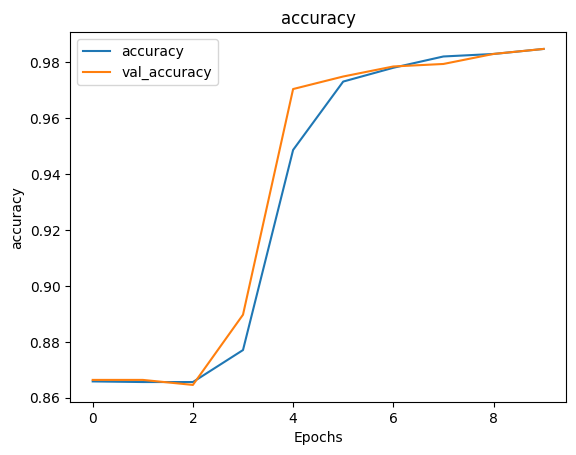

In [17]:
plot_graphs(history, "accuracy")

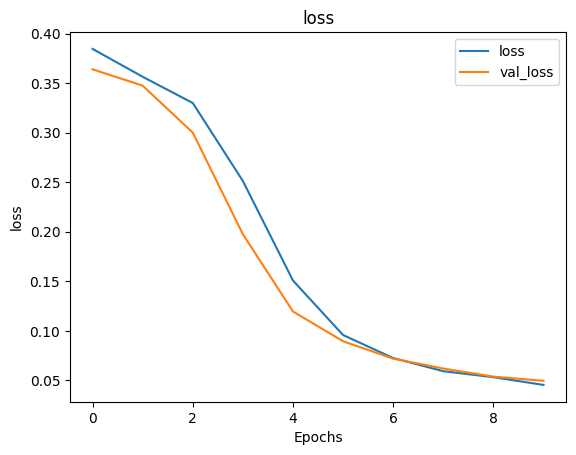

In [18]:
plot_graphs(history, "loss")

## Zaključak

U okviru projekta razvijen je model zasnovan na vještačkoj neuronskoj mreži za klasifikaciju SMS poruka na spam i ham kategorije. Prije treniranja izvršena je obrada tekstualnih podataka kroz tokenizaciju i padding sekvenci kako bi podaci bili pogodni za rad sa neuronskom mrežom.

Nakon treniranja model je evaluiran na testnom skupu podataka i ostvario je tačnost od približno 98%. Rezultati konfuzijske matrice pokazali su da model uspješno prepoznaje i legitimne i neželjene poruke, uz mali broj pogrešnih klasifikacija.

Dobijeni rezultati pokazuju da su vještačke neuronske mreže efikasan pristup za rješavanje problema detekcije spam poruka te da model može uspješno klasifikovati nove SMS poruke na osnovu njihovog sadržaja.
